# Credit Card Fraud Detection & Fraud Analytics Dashboard
### Project By : Monalisa Mudliar
### Objective
The objective of this project is to analyze credit card transactions,identify fradulent transactions using machine learning , and present business insights through an interactive dashboard.

## 1 . Import Libraries

In [8]:
import pandas as pd
import numpy as np 

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
        accuracy_score,
        confusion_matrix,
        classification_report,
        precision_score,
        recall_score,
        f1_score
)
from sklearn.ensemble import RandomForestClassifier
import joblib

## 2. Load Dataset

In [9]:
df = pd.read_csv("creditcard.csv")

In [10]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 3. Business Understanding
### Problem Statement 
Credit card fraud is one of the major challenges faced by financial instituions.
The objective of this project is to analyze transaction data , understand fraud patterns , build a machine learning model to detect fradulent transactions , and provide business insights for fraud prevention.

## 4. Data Understanding 
### 4.1 Display first five rows

In [11]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [12]:
df.shape

(284807, 31)

In [13]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

## 5 . Data cleaning
### 5.1 Chek Missing Values

In [14]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

### Observation 
There are no missing values in the dataset. Therefore, no missing value treatment is required before proceeding with further analysis. 

In [15]:
df.duplicated().sum()

np.int64(1081)

In [16]:
df = df.drop_duplicates()

In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
df.shape

(283726, 31)

### Observation 
THe dataset originally contained 1081,duplicate rows.
These duplicate records were removed using drop_duplicates().
After removal , the dataset containes 283726 unique transactions and no duplicates records remain. 

## 6. Exploratory DAta Analysis (EDA)
### 6.1 Class Distribution

In [19]:
df['Class'].value_counts()

Class
0    283253
1       473
Name: count, dtype: int64

In [20]:
class_counts = df['Class'].value_counts()
class_counts

Class
0    283253
1       473
Name: count, dtype: int64

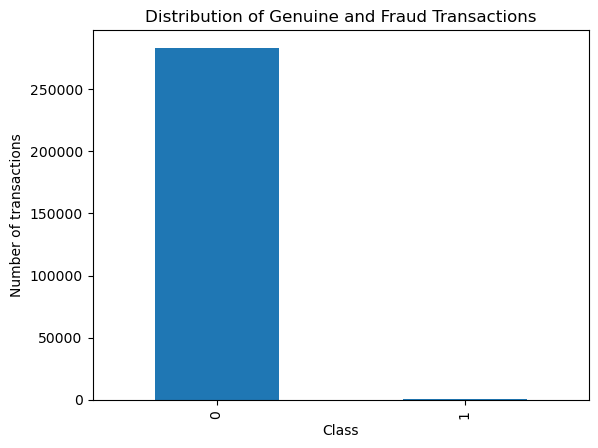

In [21]:
class_counts.plot(kind = 'bar')
plt.title("Distribution of Genuine and Fraud Transactions")
plt.xlabel("Class")
plt.ylabel("Number of transactions")
plt.show()

### Observation
The bar chart shows that genuine transacctions are significantly higher than fradulent transactions.
This indicates that the dataset is highly imbalanced , as fradulent transactions represent only a very small portion of the total transactions.
This imbalance should be considered while evaluating the machine learning model.    
    

In [22]:
df.shape

(283726, 31)

In [23]:
#total number of transactions
total_transactions = df.shape[0]
print(total_transactions)

283726


In [24]:
#Total fraud transactions
fraud_transactions = df['Class'].value_counts()[1]
print(fraud_transactions)

473


In [25]:
#Fraud percentage
fraud_percentage = (fraud_transactions / total_transactions) * 100
print(fraud_percentage)

0.1667101358352777


In [26]:
print(f"Fraud Percentage : {fraud_percentage:.2f}%")

Fraud Percentage : 0.17%


### Observation 
Fradulent transactions account for only a very small percentgae of the total transactions , indicating that the dataset is highly imbalanced.
Although fraud cases are rare , they can result in significant financial losses . Therefore accurately detecting fradulent transactions is an important business objective.   

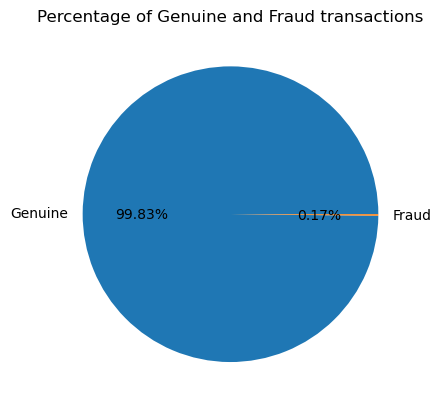

In [27]:
class_counts.plot(
    kind = 'pie',
    autopct = '%1.2f%%' , 
    labels=['Genuine','Fraud']
)
plt.title("Percentage of Genuine and Fraud transactions")
plt.ylabel("")
plt.show()

In [28]:
df['Amount'].mean()

np.float64(88.47268731099723)

In [29]:
df['Amount'].median()

22.0

In [30]:
df['Amount'].min()

0.0

In [31]:
df['Amount'].max()

25691.16

### Observation
The average transaction amount is higher than the median transaction amount.
This suggests that the dataset contains high value transactions(outliers) that increase the mean.Since the median is less affected by outliers , it better represents the typical transaction amount.    

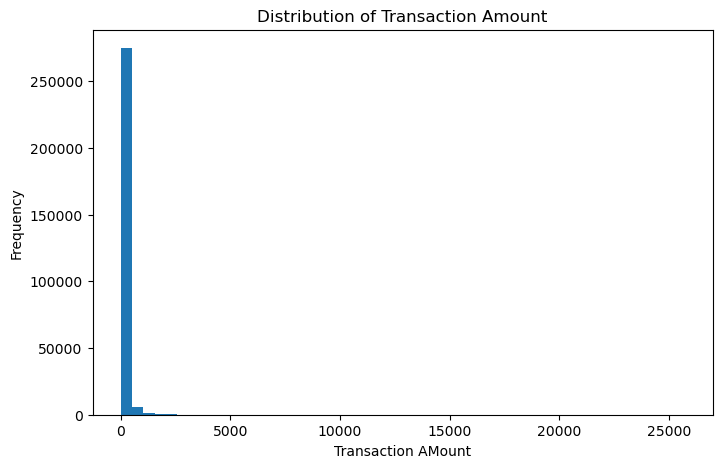

In [32]:
plt.figure(figsize=(8,5))
plt.hist(df['Amount'],bins=50)
plt.title("Distribution of Transaction Amount")
plt.xlabel("Transaction AMount")
plt.ylabel("Frequency")
plt.show()

### Observation
THe histogram shows that most transactions onvolve small amounts , while only a few transactions involve very large amounts.
 The distribution is right skewed , indicating the presence of high value transactions that may be outliers .    

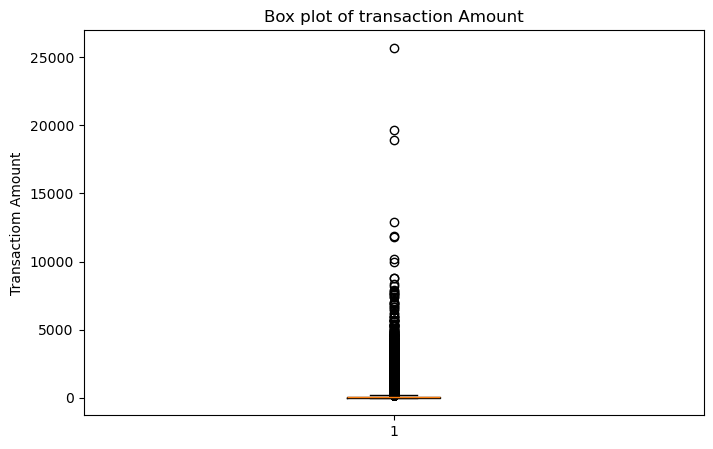

In [33]:
plt.figure(figsize=(8,5))
plt.boxplot(df['Amount'])
plt.title("Box plot of transaction Amount")
plt.ylabel("Transactiom Amount")
plt.show()

### Observation 
The box plot indicates the presence of several high value outliers in the transaction amount columns.
Most transactiobs fall within a relatively small range , while only a few transactions have exceptionally larrge amounts.These outliers may represent unusual customer behaviour and should be investigted further.    

In [34]:
df.groupby('Class')['Amount'].mean()

Class
0     88.413575
1    123.871860
Name: Amount, dtype: float64

### Observation
The average transaction amount for fraudulent transactiobs is higher than that of genuine transaction
This suggests that fraudulent transactions tend to involve larger amounts on average , although not every fraudulent transaction is high value.    

## Feature Engineering 
### Time-Based Analysis

The `Time` feature represents the number of seconds elapsed between transactions. The average transaction time was compared across genuine and fraudulent transactions to identify potential differences in transaction timing patterns.


In [35]:
df['Time'].head()

0    0.0
1    0.0
2    1.0
3    1.0
4    2.0
Name: Time, dtype: float64

In [36]:
df['Time'].describe()

count    283726.000000
mean      94811.077600
std       47481.047891
min           0.000000
25%       54204.750000
50%       84692.500000
75%      139298.000000
max      172792.000000
Name: Time, dtype: float64

In [37]:
df['Time'].head()

0    0.0
1    0.0
2    1.0
3    1.0
4    2.0
Name: Time, dtype: float64

In [38]:
df.groupby('Class')['Time'].mean()

Class
0    94835.058093
1    80450.513742
Name: Time, dtype: float64

### Observation

The average transaction time for fraudulent transactions is lower than that of genuine transactions.

This indicates that, on average, fraudulent transactions occurred earlier in the recorded time period. However, time alone is not sufficient to determine whether a transaction is fraudulent.

### Correlation Analysis 
Correlation analysis was performed to understand the relationship between the numerical features and the target variable `Class`. The correlation values range from -1 to +1, where values closer to either -1 or +1 indicate a stronger linear relationship.

In [39]:
correlation = df.corr()
correlation

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
Time,1.000000,0.117927,-0.010556,-0.422054,-0.105845,0.173223,-0.063279,0.085335,-0.038203,-0.007861,...,0.045913,0.143727,0.051474,-0.015954,-0.233262,-0.041818,-0.005171,-0.009305,-0.010559,-0.012359
V1,0.117927,1.000000,0.006875,-0.008112,0.002257,-0.007036,0.000413,-0.009173,-0.001168,0.001828,...,0.002818,-0.001436,-0.001330,-0.000723,-0.000222,-0.000684,-0.015706,-0.004861,-0.230105,-0.094486
V2,-0.010556,0.006875,1.000000,0.005278,-0.001495,0.005210,-0.000594,0.007425,0.002899,-0.000274,...,-0.004897,0.001237,-0.003855,0.000701,-0.001569,0.000253,0.007555,0.001611,-0.533428,0.084624
V3,-0.422054,-0.008112,0.005278,1.000000,0.002829,-0.006879,-0.001511,-0.011721,-0.001815,-0.003579,...,0.003500,-0.000275,0.000449,-0.000072,0.000425,-0.000094,-0.007051,-0.000134,-0.212410,-0.182322
V4,-0.105845,0.002257,-0.001495,0.002829,1.000000,0.001744,-0.000880,0.004657,0.000890,0.002154,...,-0.001034,0.000115,0.000732,-0.000120,0.000162,0.000777,0.001322,0.000231,0.099514,0.129326
V5,0.173223,-0.007036,0.005210,-0.006879,0.001744,1.000000,-0.000938,-0.008709,0.001430,-0.001213,...,0.001622,-0.000559,0.001183,0.000198,0.000069,0.000390,-0.005798,-0.000820,-0.387685,-0.087812
V6,-0.063279,0.000413,-0.000594,-0.001511,-0.000880,-0.000938,1.000000,0.000436,0.003036,-0.000734,...,-0.002134,0.001104,-0.000755,0.001202,0.000697,-0.000028,0.000289,0.000925,0.216389,-0.043915
V7,0.085335,-0.009173,0.007425,-0.011721,0.004657,-0.008709,0.000436,1.000000,-0.006419,-0.004921,...,0.009010,-0.002280,0.003303,-0.000384,-0.000072,0.000624,-0.004537,0.001657,0.400408,-0.172347
V8,-0.038203,-0.001168,0.002899,-0.001815,0.000890,0.001430,0.003036,-0.006419,1.000000,0.001038,...,0.018892,-0.006156,0.004994,0.000113,0.000011,-0.001407,0.000613,-0.000099,-0.104662,0.033068
V9,-0.007861,0.001828,-0.000274,-0.003579,0.002154,-0.001213,-0.000734,-0.004921,0.001038,1.000000,...,0.000679,0.000785,0.000677,-0.000103,-0.000275,0.001253,0.008221,0.005591,-0.044123,-0.094021


In [40]:
correlation['Class'].sort_values(ascending=False)

Class     1.000000
V11       0.149067
V4        0.129326
V2        0.084624
V19       0.033631
V8        0.033068
V21       0.026357
V27       0.021892
V20       0.021486
V28       0.009682
Amount    0.005777
V22       0.004887
V26       0.004265
V25       0.003202
V15      -0.003300
V13      -0.003897
V23      -0.006333
V24      -0.007210
Time     -0.012359
V6       -0.043915
V5       -0.087812
V9       -0.094021
V1       -0.094486
V18      -0.105340
V7       -0.172347
V3       -0.182322
V16      -0.187186
V10      -0.206971
V12      -0.250711
V14      -0.293375
V17      -0.313498
Name: Class, dtype: float64

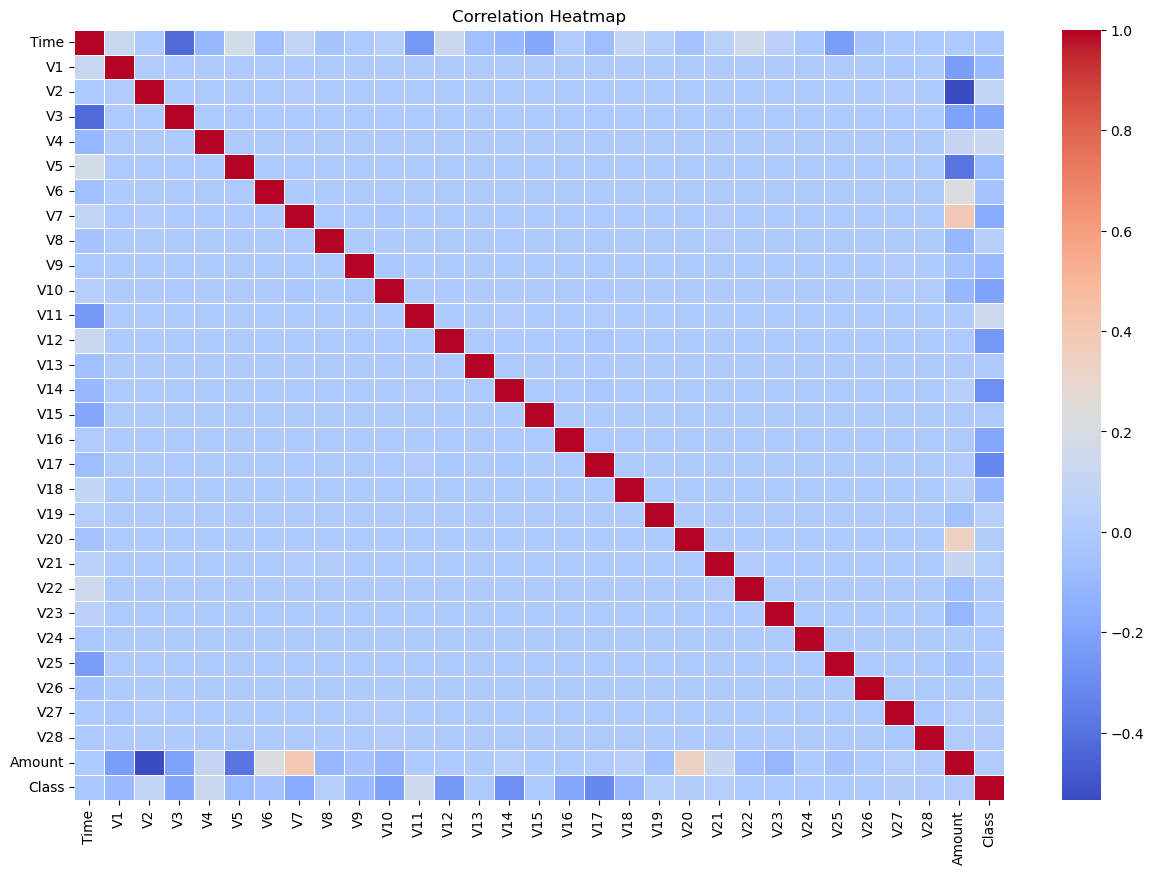

In [41]:
plt.figure(figsize=(15,10))
sns.heatmap(
    correlation,
    cmap='coolwarm',
    linewidths=0.5
)
plt.title("Correlation Heatmap")
plt.show()

### Observation

The correlation heatmap shows the relationship between all numerical features in the dataset.

Most feature pairs have weak correlations, which is why many cells appear light in color. The diagonal is dark red because every feature has a perfect correlation (1.0) with itself. The color bar indicates the strength and direction of correlation, ranging from -1 (strong negative) to +1 (strong positive).
The heatmap shows that some features have stronger correlations with the target variable than others. Features such as V14, V17, V12, and V10 showed relatively stronger correlation values with `Class`. However, correlation alone does not determine whether a transaction is fraudulent and should be interpreted along with model-based analysis.

## 7. Feature Engineering
### Feature Engineering Overview
Feature engineering involves preparing and transforming the available features so that they can be effectively used for machine learning. In this project, the existing numerical features were analyzed and prepared for model training.

### Target and Feature Separation
The `Class` column was identified as the target variable. The remaining columns were treated as input features for the machine learning model.

In [42]:
X = df.drop('Class',axis=1)
y = df['Class']

print(X.shape)
print(y.shape)


(283726, 30)
(283726,)


### Observation
The target variable 'Class' was separated from the input features.The features contain transaction related information, while 'class' represents whether the transaction is genuine or fraudulent.

##8. Feature Scaling 
### Why feature Scaling ?
Feature scaling is the process of bringing numerical features to a similar scale. In this dataset, features may have different ranges and magnitudes. Scaling helps the machine learning model process the features more effectively.

## Train Test split

### Splitting the Dataset
The dataset was divided into training and testing subsets. The training data was used to train the machine learning model, while the test data was kept separate to evaluate the model on unseen transactions.

In [43]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state = 42
)

In [44]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(226980, 30)
(56746, 30)
(226980,)
(56746,)


### Standardization Using StandardScaler
StandardScaler was used to standardize the numerical features. The transformation centers the features around a mean of 0 and scales them based on their standard deviation.

In [45]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Observation

The dataset was divided into 80% training data and 20% testing data. A fixed random state was used to ensure reproducibility of the train-test split.

## 10. Machine learning Model

### Logistic Regression

Logistic Regression was selected as the initial machine learning model for fraud classification. The model is a classification algorithm that estimates the probability of an observation belonging to a particular class.

In [46]:
model = LogisticRegression(max_iter = 1000)


In [47]:
model.fit(X_train_scaled,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


### Observation
StandardScaler was used to standardize the numerical features. The transformation centers the features around a mean of 0 and scales them based on their standard deviation.

In [48]:
print(model.coef_)

[[-0.03641587  0.08601782 -0.06404465  0.02710547  0.91823733  0.04444091
  -0.08594958 -0.1463463  -0.2070173  -0.23310899 -0.73804425  0.01709695
   0.0046095  -0.25944909 -0.57962708 -0.16972718 -0.28828039  0.13147216
   0.00345823  0.08784518 -0.25784216  0.28097673  0.50521756 -0.10274801
   0.08026386 -0.00959082  0.02427511 -0.23993822 -0.07085799  0.11627117]]


In [49]:
print(model)

LogisticRegression(max_iter=1000)


### Model Training

The Logistic Regression model was trained using the scaled training features and their corresponding target labels. The model learned patterns from the transaction features to distinguish between genuine and fraudulent transactions.

## 11. Model Prediction 
### Generating Predictions

After training the Logistic Regression model, predictions were generated on the unseen test data. The trained model was used to classify each test transaction as genuine or fraudulent.

In [50]:
y_pred = model.predict(X_test_scaled)

In [51]:
model.predict(X_test_scaled)

array([0, 0, 0, ..., 0, 0, 0], shape=(56746,))

### Observation

The model generated predicted class labels for the test transactions. These predictions were later compared with the actual target values to evaluate the performance of the model.

In [52]:
print(y_pred[:20])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


## 12. Model Evaluation
### Accuracy Evaluation
Accuracy was initially calculated to measure the overall proportion of correctly classified transactions.

In [53]:
accuracy = accuracy_score(y_test,y_pred)
print(accuracy)

0.9991893701758714


### Observation

The Logistic Regression model achieved approximately 99.92% accuracy. However, accuracy alone may be misleading in this project because the dataset is highly imbalanced, with fraudulent transactions representing a very small proportion of the data.

### Confusion Matrix

A confusion matrix was used to analyze the correct and incorrect predictions made by the model for each class.

In [54]:
cm = confusion_matrix(y_test,y_pred)
print(cm)

[[56650     6]
 [   40    50]]


### Confusion Matrix Interpretation

The confusion matrix showed 56,650 genuine transactions correctly classified as genuine and 50 fraudulent transactions correctly detected. However, 40 fraudulent transactions were incorrectly classified as genuine. Additionally, 6 genuine transactions were incorrectly classified as fraudulent.

## 13 Classification Report
### Precision, Recall and F1-Score

Precision, recall and F1-score were used to evaluate the model in greater detail, especially for the minority fraud class.

In [55]:
recall = recall_score(y_test,y_pred)
print(recall)

0.5555555555555556


In [56]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56656
           1       0.89      0.56      0.68        90

    accuracy                           1.00     56746
   macro avg       0.95      0.78      0.84     56746
weighted avg       1.00      1.00      1.00     56746



### Observation

The model achieved high precision for the fraud class, indicating that most transactions predicted as fraudulent were actually fraudulent. However, fraud recall was approximately 56%, meaning that the model failed to detect a significant number of actual fraudulent transactions. Therefore, recall was identified as an important metric for further improvement.

## 14. Handling Class Imbalance
### Balanced Logistic Regression

Since fraudulent transactions represented a minority class, `class_weight='balanced'` was tested to give greater importance to the minority fraud class during model training.

In [57]:
class_weight = 'balanced'

In [58]:
model_balanced = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

In [59]:
model_balanced.fit(X_train_scaled,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [60]:
y_pred_balanced = model_balanced.predict(X_test_scaled)

### Observation

The balanced Logistic Regression model improved fraud recall to approximately 89%. However, precision decreased significantly to approximately 6%, indicating a large number of false positives. This showed a clear trade-off between detecting more fraud cases and incorrectly flagging genuine transactions.

In [61]:
print(classification_report(y_test,y_pred_balanced))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56656
           1       0.06      0.89      0.11        90

    accuracy                           0.98     56746
   macro avg       0.53      0.93      0.55     56746
weighted avg       1.00      0.98      0.99     56746



## 15. Threshold Tuning
### Fraud Probability and Classification Threshold

The Logistic Regression model generates a probability for each class. The fraud probability was extracted and different classification thresholds were tested to study the trade-off between precision and recall.

In [62]:
y_prob = model.predict_proba(X_test_scaled)

In [63]:
print(y_prob[:5])

[[9.99510063e-01 4.89937312e-04]
 [9.99999656e-01 3.43901794e-07]
 [9.99948874e-01 5.11262435e-05]
 [9.99889391e-01 1.10609475e-04]
 [9.99495498e-01 5.04502146e-04]]


In [64]:
fraud_prob = model.predict_proba(X_test_scaled)[:, 1]

In [65]:
print(fraud_prob[:20])

[4.89937312e-04 3.43901794e-07 5.11262435e-05 1.10609475e-04
 5.04502146e-04 4.09838799e-04 6.48570404e-03 1.60482016e-04
 5.39534404e-06 2.23180623e-05 3.07067148e-04 5.72035911e-05
 7.00418069e-05 4.36828414e-04 8.61299872e-05 8.19754215e-05
 3.37948336e-04 1.27185778e-04 9.63209970e-05 4.70026131e-05]


In [66]:
y_pred_70 = (fraud_prob >= 0.70).astype(int)

In [67]:
print(classification_report(y_test,y_pred_70))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56656
           1       0.90      0.50      0.64        90

    accuracy                           1.00     56746
   macro avg       0.95      0.75      0.82     56746
weighted avg       1.00      1.00      1.00     56746



In [68]:
y_pred_30 = (fraud_prob >= 0.30).astype(int)

In [69]:
print(classification_report(y_test, y_pred_30))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56656
           1       0.83      0.61      0.71        90

    accuracy                           1.00     56746
   macro avg       0.92      0.81      0.85     56746
weighted avg       1.00      1.00      1.00     56746



### Threshold Comparison Observation

Different classification thresholds were tested to evaluate the precision-recall trade-off. Lowering the threshold from 0.50 to 0.30 made the model more sensitive to potential fraud cases. This improved fraud recall from approximately 56% to 61%, while precision decreased from approximately 89% to 83%.


### Systematic Threshold Analysis

Multiple classification thresholds were evaluated to identify a suitable balance between precision and recall for fraud detection. The performance of the model was compared across different thresholds using precision, recall and F1-score.

In [70]:
thresholds = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]

In [71]:
threshold_results = []

In [72]:
from sklearn.metrics import precision_score, recall_score, f1_score

for threshold in thresholds:
    
    y_pred_threshold = (fraud_prob >= threshold).astype(int)
    
    precision = precision_score(y_test, y_pred_threshold)
    recall = recall_score(y_test, y_pred_threshold)
    f1 = f1_score(y_test, y_pred_threshold)
    
    threshold_results.append({
        'Threshold': threshold,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    })

In [73]:
threshold_df = pd.DataFrame(threshold_results)

In [74]:
print(threshold_df)

    Threshold  Precision    Recall  F1-Score
0        0.10   0.768293  0.700000  0.732558
1        0.15   0.805556  0.644444  0.716049
2        0.20   0.814286  0.633333  0.712500
3        0.25   0.826087  0.633333  0.716981
4        0.30   0.833333  0.611111  0.705128
5        0.35   0.870968  0.600000  0.710526
6        0.40   0.868852  0.588889  0.701987
7        0.45   0.879310  0.566667  0.689189
8        0.50   0.892857  0.555556  0.684932
9        0.55   0.886792  0.522222  0.657343
10       0.60   0.886792  0.522222  0.657343
11       0.65   0.900000  0.500000  0.642857
12       0.70   0.900000  0.500000  0.642857


### Threshold Analysis Observation

The classification threshold was varied to study its impact on fraud detection performance. A lower threshold made the model more sensitive to potential fraud transactions and improved fraud recall. Among the tested thresholds, a threshold of 0.10 achieved the highest F1-score of approximately 0.73, with a precision of 76.83% and recall of 70%. This provided the best balance between precision and recall among the tested thresholds.

## 16. Model Improvement Using Random Forest
### Random Forest Classifier

Random Forest was selected as a second machine learning model to compare its performance with Logistic Regression. Random Forest is an ensemble learning algorithm that combines multiple decision trees to identify patterns in the data.

### Why Random Forest?

Random Forest was selected as a second model because it can capture complex and non-linear relationships between features. Its performance was compared with Logistic Regression to determine whether it could improve fraud detection.

In [75]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

In [76]:
rf_model.fit(X_train_scaled,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [77]:
class_weight = 'balanced'

### Model Training

The Random Forest model was trained using 100 decision trees. Each tree learned patterns from the transaction features, and the final prediction was determined using the combined results of the individual trees.

In [78]:
y_pred_rf = rf_model.predict(X_test_scaled)

In [79]:
print(classification_report(y_test,y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56656
           1       0.97      0.73      0.84        90

    accuracy                           1.00     56746
   macro avg       0.99      0.87      0.92     56746
weighted avg       1.00      1.00      1.00     56746



### Random Forest Evaluation

The Random Forest model achieved a fraud precision of 97%, recall of 73% and F1-score of 84%. Compared with the Logistic Regression model, Random Forest showed improved fraud detection while maintaining high precision. This suggests that Random Forest was better able to capture the complex patterns associated with fraudulent transactions in the dataset.

## 17. Model Comparison
### Comparing Machine Learning Models

Logistic and Random Forest were evaluated and compared using fraud-class precision, recall and F1-score. Since the dataset is highly imbalanced, the fraud-class metrics were given greater importance than accuracy alone.

In [80]:
model_comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Logistic Regression (Threshold 0.10)',
        'Random Forest'
    ],
    'Precision': [
        0.89,
        0.7683,
        0.97
    ],
    'Recall': [
        0.5556,
        0.70,
        0.73
    ],
    'F1-Score': [
        0.6849,
        0.7326,
        0.84
    ]
})

In [81]:
model_comparison

,Model,Precision,Recall,F1-Score
0,Logistic Regression,0.8900,0.5556,0.6849
1,Logistic Regression (Threshold 0.10),0.7683,0.7000,0.7326
2,Random Forest,0.9700,0.7300,0.8400


### Model Comparison Observation

Random Forest achieved the best overall fraud-class performance among the evaluated approaches. It achieved a precision of 97%, recall of 73% and F1-score of 84%. Although threshold tuning improved the recall of Logistic Regression, Random Forest provided a better balance between fraud detection and false positive control. Therefore, Random Forest was selected as the final machine learning model for the fraud detection system.

### Final Model Selection

Based on the comparison of precision, recall and F1-score for the fraud class, Random Forest was selected as the final model. It achieved the highest F1-score of 84%, along with 97% precision and 73% recall. The model provided a better balance between detecting fraudulent transactions and minimizing false fraud alerts compared with the evaluated Logistic Regression approaches.

## 18. Fraud Risk Output

The final Random Forest model was used to generate fraud probabilities for each test transaction. These probabilities were converted into risk scores and risk levels to make the model output easier to interpret in a fraud monitoring system.

In [82]:
rf_fraud_probability = rf_model.predict_proba(X_test_scaled)[:, 1]

In [83]:
rf_prediction = (rf_fraud_probability >= 0.50).astype(int)

In [84]:
risk_level = pd.cut(
    rf_fraud_probability,
    bins=[-1, 0.30, 0.70, 1.00],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

In [85]:
fraud_output = pd.DataFrame({
    'Actual Class': y_test.values,
    'Fraud Probability': rf_fraud_probability,
    'Prediction': rf_prediction,
    'Risk Level': risk_level
})

In [86]:
fraud_output.head(10)

,Actual Class,Fraud Probability,Prediction,Risk Level
0,0,0.0,0,Low Risk
1,0,0.0,0,Low Risk
2,0,0.0,0,Low Risk
3,0,0.0,0,Low Risk
4,0,0.0,0,Low Risk
5,0,0.0,0,Low Risk
6,0,0.0,0,Low Risk
7,0,0.0,0,Low Risk
8,0,0.0,0,Low Risk
9,0,0.0,0,Low Risk


In [87]:
df[['Time','Amount','Class']].head()

,Time,Amount,Class
0,0.0,149.62,0
1,0.0,2.69,0
2,1.0,378.66,0
3,1.0,123.50,0
4,2.0,69.99,0


In [88]:
fraud_output = X_test[['Time', 'Amount']].copy()

In [89]:
fraud_output['Fraud Probability'] = rf_fraud_probability

In [90]:
fraud_output['Prediction'] = rf_prediction

In [91]:
fraud_output['Risk Level'] = risk_level

In [92]:
fraud_output['Transaction ID'] = [
    f'TXN_{i:06d}' for i in range(1, len(fraud_output) + 1)
]

In [93]:
fraud_output = fraud_output[
    [
        'Transaction ID',
        'Time',
        'Amount',
        'Fraud Probability',
        'Prediction',
        'Risk Level'
    ]
]

In [94]:
fraud_output.head(10)

,Transaction ID,Time,Amount,Fraud Probability,Prediction,Risk Level
104697,TXN_000001,69195.0,56.42,0.0,0,Low Risk
134356,TXN_000002,80769.0,9.82,0.0,0,Low Risk
42637,TXN_000003,41182.0,46.08,0.0,0,Low Risk
882,TXN_000004,666.0,3.58,0.0,0,Low Risk
263275,TXN_000005,160870.0,2.84,0.0,0,Low Risk
17269,TXN_000006,28583.0,76.50,0.0,0,Low Risk
40536,TXN_000007,40280.0,83.00,0.0,0,Low Risk
275379,TXN_000008,166502.0,10.99,0.0,0,Low Risk
146750,TXN_000009,87862.0,1.00,0.0,0,Low Risk
138011,TXN_000010,82444.0,10.84,0.0,0,Low Risk


In [95]:
fraud_output['Prediction'] = fraud_output['Prediction'].map({
    0: 'Genuine',
    1: 'Fraud'
})

In [96]:
fraud_output.head(10)

,Transaction ID,Time,Amount,Fraud Probability,Prediction,Risk Level
104697,TXN_000001,69195.0,56.42,0.0,Genuine,Low Risk
134356,TXN_000002,80769.0,9.82,0.0,Genuine,Low Risk
42637,TXN_000003,41182.0,46.08,0.0,Genuine,Low Risk
882,TXN_000004,666.0,3.58,0.0,Genuine,Low Risk
263275,TXN_000005,160870.0,2.84,0.0,Genuine,Low Risk
17269,TXN_000006,28583.0,76.50,0.0,Genuine,Low Risk
40536,TXN_000007,40280.0,83.00,0.0,Genuine,Low Risk
275379,TXN_000008,166502.0,10.99,0.0,Genuine,Low Risk
146750,TXN_000009,87862.0,1.00,0.0,Genuine,Low Risk
138011,TXN_000010,82444.0,10.84,0.0,Genuine,Low Risk


In [97]:
fraud_output['Risk Score (%)'] = (
    fraud_output['Fraud Probability'] * 100
).round(2)

In [98]:
fraud_output.head(10)

,Transaction ID,Time,Amount,Fraud Probability,Prediction,Risk Level,Risk Score (%)
104697,TXN_000001,69195.0,56.42,0.0,Genuine,Low Risk,0.0
134356,TXN_000002,80769.0,9.82,0.0,Genuine,Low Risk,0.0
42637,TXN_000003,41182.0,46.08,0.0,Genuine,Low Risk,0.0
882,TXN_000004,666.0,3.58,0.0,Genuine,Low Risk,0.0
263275,TXN_000005,160870.0,2.84,0.0,Genuine,Low Risk,0.0
17269,TXN_000006,28583.0,76.50,0.0,Genuine,Low Risk,0.0
40536,TXN_000007,40280.0,83.00,0.0,Genuine,Low Risk,0.0
275379,TXN_000008,166502.0,10.99,0.0,Genuine,Low Risk,0.0
146750,TXN_000009,87862.0,1.00,0.0,Genuine,Low Risk,0.0
138011,TXN_000010,82444.0,10.84,0.0,Genuine,Low Risk,0.0


### Business-Friendly Risk Output

The model predictions were converted into business-friendly labels such as Genuine and Fraud. Fraud probabilities were also converted into percentage-based risk scores to improve interpretability for fraud analysts and support the development of a fraud monitoring interface.

In [99]:
fraud_output['Risk Level'].value_counts()

Risk Level
Low Risk       56669
High Risk         59
Medium Risk       18
Name: count, dtype: int64

In [100]:
fraud_output = fraud_output.reset_index(drop=True)

In [101]:
fraud_output.head(10)

,Transaction ID,Time,Amount,Fraud Probability,Prediction,Risk Level,Risk Score (%)
0,TXN_000001,69195.0,56.42,0.0,Genuine,Low Risk,0.0
1,TXN_000002,80769.0,9.82,0.0,Genuine,Low Risk,0.0
2,TXN_000003,41182.0,46.08,0.0,Genuine,Low Risk,0.0
3,TXN_000004,666.0,3.58,0.0,Genuine,Low Risk,0.0
4,TXN_000005,160870.0,2.84,0.0,Genuine,Low Risk,0.0
5,TXN_000006,28583.0,76.50,0.0,Genuine,Low Risk,0.0
6,TXN_000007,40280.0,83.00,0.0,Genuine,Low Risk,0.0
7,TXN_000008,166502.0,10.99,0.0,Genuine,Low Risk,0.0
8,TXN_000009,87862.0,1.00,0.0,Genuine,Low Risk,0.0
9,TXN_000010,82444.0,10.84,0.0,Genuine,Low Risk,0.0


In [102]:
fraud_alerts = fraud_output[
    fraud_output['Risk Level'].isin(['High Risk', 'Medium Risk'])
].copy()

In [103]:
print(fraud_alerts.shape)

(77, 7)


In [104]:
fraud_alerts.head(10)

,Transaction ID,Time,Amount,Fraud Probability,Prediction,Risk Level,Risk Score (%)
270,TXN_000271,48884.0,19.73,0.52,Fraud,Medium Risk,52.0
327,TXN_000328,152058.0,1.00,0.99,Fraud,High Risk,99.0
2541,TXN_002542,28755.0,99.99,0.76,Fraud,High Risk,76.0
2731,TXN_002732,35261.0,2.69,0.77,Fraud,High Risk,77.0
2995,TXN_002996,85576.0,240.77,0.93,Fraud,High Risk,93.0
4828,TXN_004829,17520.0,1.00,0.95,Fraud,High Risk,95.0
6045,TXN_006046,154599.0,6.74,0.99,Fraud,High Risk,99.0
6758,TXN_006759,100501.0,0.76,0.79,Fraud,High Risk,79.0
6778,TXN_006779,34256.0,19.02,0.61,Fraud,Medium Risk,61.0
6998,TXN_006999,138894.0,0.01,0.91,Fraud,High Risk,91.0


In [105]:
fraud_alerts_evaluation = fraud_alerts.copy()

fraud_alerts_evaluation['Actual Class'] = y_test.iloc[
    fraud_alerts.index
].values

In [106]:
alert_mask = fraud_output['Risk Level'].isin(
    ['High Risk', 'Medium Risk']
)

In [107]:
fraud_alerts_evaluation = fraud_output[alert_mask].copy()

In [108]:
fraud_alerts_evaluation['Actual Class'] = y_test.reset_index(
    drop=True
)[alert_mask.values].values

In [109]:
fraud_alerts_evaluation['Actual Class'].value_counts()

Actual Class
1    69
0     8
Name: count, dtype: int64

### Fraud Alert Evaluation

The fraud alert system identified 77 medium- and high-risk transactions. Of these, 69 were actual fraudulent transactions and 8 were genuine transactions. The alert system achieved an alert precision of 89.61% and captured 76.67% of the actual fraud transactions in the test set. This indicates that the risk-based alerting approach can help prioritize suspicious transactions for fraud analyst review.

## 19. Final Fraud Monitoring Dataset

In [110]:
final_fraud_dataset = fraud_output.copy()

In [111]:
final_fraud_dataset['Actual Class'] = y_test.reset_index(
    drop=True
)

In [112]:
final_fraud_dataset['Actual Status'] = final_fraud_dataset[
    'Actual Class'
].map({
    0: 'Genuine',
    1: 'Fraud'
})

In [113]:
final_fraud_dataset = final_fraud_dataset[
    [
        'Transaction ID',
        'Time',
        'Amount',
        'Fraud Probability',
        'Risk Score (%)',
        'Prediction',
        'Risk Level',
        'Actual Status'
    ]
]

In [114]:
final_fraud_dataset.head()

,Transaction ID,Time,Amount,Fraud Probability,Risk Score (%),Prediction,Risk Level,Actual Status
0,TXN_000001,69195.0,56.42,0.0,0.0,Genuine,Low Risk,Genuine
1,TXN_000002,80769.0,9.82,0.0,0.0,Genuine,Low Risk,Genuine
2,TXN_000003,41182.0,46.08,0.0,0.0,Genuine,Low Risk,Genuine
3,TXN_000004,666.0,3.58,0.0,0.0,Genuine,Low Risk,Genuine
4,TXN_000005,160870.0,2.84,0.0,0.0,Genuine,Low Risk,Genuine


In [115]:
final_fraud_dataset.head()

,Transaction ID,Time,Amount,Fraud Probability,Risk Score (%),Prediction,Risk Level,Actual Status
0,TXN_000001,69195.0,56.42,0.0,0.0,Genuine,Low Risk,Genuine
1,TXN_000002,80769.0,9.82,0.0,0.0,Genuine,Low Risk,Genuine
2,TXN_000003,41182.0,46.08,0.0,0.0,Genuine,Low Risk,Genuine
3,TXN_000004,666.0,3.58,0.0,0.0,Genuine,Low Risk,Genuine
4,TXN_000005,160870.0,2.84,0.0,0.0,Genuine,Low Risk,Genuine


### Time Feature Transformation

The Time feature represents elapsed seconds from the first transaction. It was converted into transaction hours to improve business interpretability and support time-based fraud analysis.

In [116]:
final_fraud_dataset['Transaction Hour'] = (
    final_fraud_dataset['Time'] / 3600
).round(2)

In [117]:
final_fraud_dataset.head()

,Transaction ID,Time,Amount,Fraud Probability,Risk Score (%),Prediction,Risk Level,Actual Status,Transaction Hour
0,TXN_000001,69195.0,56.42,0.0,0.0,Genuine,Low Risk,Genuine,19.22
1,TXN_000002,80769.0,9.82,0.0,0.0,Genuine,Low Risk,Genuine,22.44
2,TXN_000003,41182.0,46.08,0.0,0.0,Genuine,Low Risk,Genuine,11.44
3,TXN_000004,666.0,3.58,0.0,0.0,Genuine,Low Risk,Genuine,0.18
4,TXN_000005,160870.0,2.84,0.0,0.0,Genuine,Low Risk,Genuine,44.69


In [118]:
print(final_fraud_dataset.columns)

Index(['Transaction ID', 'Time', 'Amount', 'Fraud Probability',
       'Risk Score (%)', 'Prediction', 'Risk Level', 'Actual Status',
       'Transaction Hour'],
      dtype='object')


In [119]:
final_fraud_dataset[['Time', 'Transaction Hour']].head()

,Time,Transaction Hour
0,69195.0,19.22
1,80769.0,22.44
2,41182.0,11.44
3,666.0,0.18
4,160870.0,44.69


In [120]:
final_fraud_dataset.groupby(
    'Actual Status'
)['Transaction Hour'].mean()

Actual Status
Fraud      22.947333
Genuine    26.371003
Name: Transaction Hour, dtype: float64

### Time-Based Fraud Insight

Fraudulent transactions had an average elapsed transaction time of 22.95 hours, compared with 26.37 hours for genuine transactions. This indicates that fraudulent transactions occurred approximately 3.42 hours earlier on average in the dataset timeline. However, since the Time feature represents elapsed time rather than actual time of day, this insight should be interpreted as a temporal pattern within the dataset rather than a specific time-of-day fraud pattern.

In [121]:
final_fraud_dataset.groupby(
    'Actual Status'
)['Amount'].agg(['mean', 'median', 'max'])

,mean,median,max
Actual Status,,,
Fraud,178.081778,29.51,1504.93
Genuine,88.201171,22.00,12910.93


### Transaction Amount Fraud Insight

Fraudulent transactions had a higher average transaction amount of 178.08 compared with 88.20 for genuine transactions, indicating that fraudulent transactions were approximately twice as large on average. However, the median amounts were relatively close, suggesting a skewed fraud amount distribution. Additionally, the maximum genuine transaction amount was substantially higher than the maximum fraud amount. This demonstrates that transaction amount alone is not a reliable indicator of fraud and must be analyzed along with other transaction features.

In [122]:
powerbi_dataset = final_fraud_dataset[
    [
        'Transaction ID',
        'Transaction Hour',
        'Amount',
        'Fraud Probability',
        'Risk Score (%)',
        'Prediction',
        'Risk Level',
        'Actual Status'
    ]
].copy()

In [123]:
powerbi_dataset.head()

,Transaction ID,Transaction Hour,Amount,Fraud Probability,Risk Score (%),Prediction,Risk Level,Actual Status
0,TXN_000001,19.22,56.42,0.0,0.0,Genuine,Low Risk,Genuine
1,TXN_000002,22.44,9.82,0.0,0.0,Genuine,Low Risk,Genuine
2,TXN_000003,11.44,46.08,0.0,0.0,Genuine,Low Risk,Genuine
3,TXN_000004,0.18,3.58,0.0,0.0,Genuine,Low Risk,Genuine
4,TXN_000005,44.69,2.84,0.0,0.0,Genuine,Low Risk,Genuine


In [124]:
%whos

Variable                  Type                      Data/Info
-------------------------------------------------------------
LogisticRegression        type                      <class 'sklearn.linear_mo<...>stic.LogisticRegression'>
RandomForestClassifier    ABCMeta                   <class 'sklearn.ensemble.<...>.RandomForestClassifier'>
StandardScaler            type                      <class 'sklearn.preproces<...>ng._data.StandardScaler'>
X                         DataFrame                 Shape: (283726, 30)
X_test                    DataFrame                 Shape: (56746, 30)
X_test_scaled             ndarray                   56746x30: 1702380 elems, type `float64`, 13619040 bytes (12.988128662109375 Mb)
X_train                   DataFrame                 Shape: (226980, 30)
X_train_scaled            ndarray                   226980x30: 6809400 elems, type `float64`, 54475200 bytes (51.95159912109375 Mb)
accuracy                  float                     0.9991893701758714
ac

In [125]:
joblib.dump(
    rf_model,
    r'C:\Users\admin\Downloads\Credit Card Fraud Detection\Python\Model\fraud_model.pkl'
)

['C:\\Users\\admin\\Downloads\\Credit Card Fraud Detection\\Python\\Model\\fraud_model.pkl']

In [126]:
import os 
os.getcwd()

'C:\\Users\\admin\\Downloads\\Credit Card Fraud Detection\\Python'

In [127]:
joblib.dump(
    scaler,
    r'C:\Users\admin\Downloads\Credit Card Fraud Detection\Python\Model\scaler.pkl'
)

['C:\\Users\\admin\\Downloads\\Credit Card Fraud Detection\\Python\\Model\\scaler.pkl']

In [128]:
df.iloc[0][
    ['Time'] + [f'V{i}' for i in range(1, 29)] + ['Amount']
].to_dict()

{'Time': 0.0,
 'V1': -1.3598071336738,
 'V2': -0.0727811733098497,
 'V3': 2.53634673796914,
 'V4': 1.37815522427443,
 'V5': -0.338320769942518,
 'V6': 0.462387777762292,
 'V7': 0.239598554061257,
 'V8': 0.0986979012610507,
 'V9': 0.363786969611213,
 'V10': 0.0907941719789316,
 'V11': -0.551599533260813,
 'V12': -0.617800855762348,
 'V13': -0.991389847235408,
 'V14': -0.311169353699879,
 'V15': 1.46817697209427,
 'V16': -0.470400525259478,
 'V17': 0.207971241929242,
 'V18': 0.0257905801985591,
 'V19': 0.403992960255733,
 'V20': 0.251412098239705,
 'V21': -0.018306777944153,
 'V22': 0.277837575558899,
 'V23': -0.110473910188767,
 'V24': 0.0669280749146731,
 'V25': 0.128539358273528,
 'V26': -0.189114843888824,
 'V27': 0.133558376740387,
 'V28': -0.0210530534538215,
 'Amount': 149.62}

## Second model

In [129]:
business_features = df[['Time', 'Amount', 'Class']].copy()

In [130]:
business_features['Transaction Hour'] = (
    business_features['Time'] / 3600
) % 24

In [131]:
business_features['Log Amount'] = np.log1p(
    business_features['Amount']
)

In [132]:
business_features.head()

,Time,Amount,Class,Transaction Hour,Log Amount
0,0.0,149.62,0,0.000000,5.014760
1,0.0,2.69,0,0.000000,1.305626
2,1.0,378.66,0,0.000278,5.939276
3,1.0,123.50,0,0.000278,4.824306
4,2.0,69.99,0,0.000556,4.262539


In [133]:
business_X = business_features[
    ['Amount', 'Log Amount']
]

business_y = business_features['Class']

In [134]:
business_X.head()

,Amount,Log Amount
0,149.62,5.014760
1,2.69,1.305626
2,378.66,5.939276
3,123.50,4.824306
4,69.99,4.262539


In [135]:
X_train_business, X_test_business, y_train_business, y_test_business = train_test_split(
    business_X,
    business_y,
    test_size=0.2,
    random_state=42,
    stratify=business_y
)

In [136]:
business_X.head()

,Amount,Log Amount
0,149.62,5.014760
1,2.69,1.305626
2,378.66,5.939276
3,123.50,4.824306
4,69.99,4.262539


In [137]:
business_rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

business_rf_model.fit(
    X_train_business,
    y_train_business
)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [138]:
business_y_pred = business_rf_model.predict(
    X_test_business
)

In [139]:
print(classification_report(
    y_test_business,
    business_y_pred
))

              precision    recall  f1-score   support

           0       1.00      0.90      0.95     56651
           1       0.01      0.48      0.02        95

    accuracy                           0.90     56746
   macro avg       0.50      0.69      0.48     56746
weighted avg       1.00      0.90      0.95     56746



In [140]:
import joblib

joblib.dump(rf_model, "rf_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model Saved Successfully")

Model Saved Successfully


In [141]:
import os

print(os.getcwd())

C:\Users\admin\Downloads\Credit Card Fraud Detection\Python


In [142]:
import os

print(os.listdir())

['.ipynb_checkpoints', 'API', 'creditcard.csv', 'credit_card_fraud.ipynb', 'Credit_Card_Fraud_Detection_Project.ipynb', 'data', 'Model', 'rf_model.pkl', 'scaler.pkl', 'Untitled.ipynb']


In [143]:
import os

for file in os.listdir():
    print(file)

.ipynb_checkpoints
API
creditcard.csv
credit_card_fraud.ipynb
Credit_Card_Fraud_Detection_Project.ipynb
data
Model
rf_model.pkl
scaler.pkl
Untitled.ipynb
